<a href="https://colab.research.google.com/github/RithwikRajSuram/Public-Health-Trends-Analysis-based-on-Tobacco-Use-and-Mortality-Patterns/blob/main/public-health-tobacco-mortality-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
tobacco_use_df = pd.read_csv('/content/Behavioral_Risk_Factor_Data__Tobacco_Use.csv')
deaths_df = pd.read_csv('/content/Monthly_Provisional_Counts_of_Deaths_2020-2023.csv')

In [27]:
tobacco_use_df

,YEAR,LocationAbbr,LocationDesc,TopicType,TopicDesc,MeasureDesc,DataSource,Response,Data_Value_Unit,Data_Value_Type,...,GeoLocation,TopicTypeId,TopicId,MeasureId,StratificationID1,StratificationID2,StratificationID3,StratificationID4,SubMeasureID,DisplayOrder
0,2017,GU,Guam,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking,BRFSS,NaN,%,Percentage,...,"(13.444304, 144.793731)",BEH,100BEH,110CSA,2GEN,8AGE,6RAC,6EDU,BRF21,21
1,2018,US,National Median (States and DC),Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Current,%,Percentage,...,NaN,BEH,100BEH,165SSA,1GEN,8AGE,6RAC,6EDU,BRF27,27
2,2017,US,National Median (States and DC),Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Never,%,Percentage,...,NaN,BEH,100BEH,165SSA,1GEN,8AGE,6RAC,6EDU,BRF28,28
3,2016,GU,Guam,Tobacco Use – Survey Data,Smokeless Tobacco Use (Adults),Current Use,BRFSS,NaN,%,Percentage,...,"(13.444304, 144.793731)",BEH,150BEH,177SCU,1GEN,8AGE,4RAC,6EDU,BRF69,69
4,2014,GU,Guam,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking,BRFSS,NaN,%,Percentage,...,"(13.444304, 144.793731)",BEH,100BEH,110CSA,1GEN,8AGE,5RAC,6EDU,BRF22,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43336,2011,RI,Rhode Island,Tobacco Use – Survey Data,Smokeless Tobacco Use (Adults),Current Use,BRFSS,NaN,%,Percentage,...,"(41.70828019300046, -71.52247031399963)",BEH,150BEH,177SCU,1GEN,4AGE,6RAC,6EDU,BRF70,70
43337,2013-2014,MA,Massachusetts,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking – (2 yrs – Race/Ethnicity),BRFSS,NaN,%,Percentage,...,"(42.27687047000046, -72.08269067499964)",BEH,100BEH,112CS2,1GEN,8AGE,3RAC,6EDU,BRF32,32
43338,2015,AK,Alaska,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking,BRFSS,NaN,%,Percentage,...,"(64.84507995700051, -147.72205903599973)",BEH,100BEH,110CSA,1GEN,6AGE,6RAC,4EDU,BRF24,24
43339,2014,IA,Iowa,Tobacco Use – Survey Data,Smokeless Tobacco Use (Adults),User Status,BRFSS,Current,%,Percentage,...,"(42.46940091300047, -93.81649055599968)",BEH,150BEH,179SUS,2GEN,8AGE,6RAC,6EDU,BRF80,80


In [28]:
tobacco_use_df.head()

,YEAR,LocationAbbr,LocationDesc,TopicType,TopicDesc,MeasureDesc,DataSource,Response,Data_Value_Unit,Data_Value_Type,...,GeoLocation,TopicTypeId,TopicId,MeasureId,StratificationID1,StratificationID2,StratificationID3,StratificationID4,SubMeasureID,DisplayOrder
0,2017,GU,Guam,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking,BRFSS,NaN,%,Percentage,...,"(13.444304, 144.793731)",BEH,100BEH,110CSA,2GEN,8AGE,6RAC,6EDU,BRF21,21
1,2018,US,National Median (States and DC),Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Current,%,Percentage,...,NaN,BEH,100BEH,165SSA,1GEN,8AGE,6RAC,6EDU,BRF27,27
2,2017,US,National Median (States and DC),Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Never,%,Percentage,...,NaN,BEH,100BEH,165SSA,1GEN,8AGE,6RAC,6EDU,BRF28,28
3,2016,GU,Guam,Tobacco Use – Survey Data,Smokeless Tobacco Use (Adults),Current Use,BRFSS,NaN,%,Percentage,...,"(13.444304, 144.793731)",BEH,150BEH,177SCU,1GEN,8AGE,4RAC,6EDU,BRF69,69
4,2014,GU,Guam,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking,BRFSS,NaN,%,Percentage,...,"(13.444304, 144.793731)",BEH,100BEH,110CSA,1GEN,8AGE,5RAC,6EDU,BRF22,22


In [29]:
tobacco_use_df.columns

Index(['YEAR', 'LocationAbbr', 'LocationDesc', 'TopicType', 'TopicDesc',
       'MeasureDesc', 'DataSource', 'Response', 'Data_Value_Unit',
       'Data_Value_Type', 'Data_Value', 'Data_Value_Footnote_Symbol',
       'Data_Value_Footnote', 'Data_Value_Std_Err', 'Low_Confidence_Limit',
       'High_Confidence_Limit', 'Sample_Size', 'Gender', 'Race', 'Age',
       'Education', 'GeoLocation', 'TopicTypeId', 'TopicId', 'MeasureId',
       'StratificationID1', 'StratificationID2', 'StratificationID3',
       'StratificationID4', 'SubMeasureID', 'DisplayOrder'],
      dtype='object')

In [30]:
tobacco_use_df.shape

(43341, 31)

In [31]:
tobacco_use_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43341 entries, 0 to 43340
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   YEAR                        43341 non-null  object 
 1   LocationAbbr                43341 non-null  object 
 2   LocationDesc                43341 non-null  object 
 3   TopicType                   43341 non-null  object 
 4   TopicDesc                   43341 non-null  object 
 5   MeasureDesc                 43341 non-null  object 
 6   DataSource                  43341 non-null  object 
 7   Response                    15018 non-null  object 
 8   Data_Value_Unit             43341 non-null  object 
 9   Data_Value_Type             43341 non-null  object 
 10  Data_Value                  41224 non-null  float64
 11  Data_Value_Footnote_Symbol  2117 non-null   object 
 12  Data_Value_Footnote         2117 non-null   object 
 13  Data_Value_Std_Err          411

In [32]:
# Identify missing values in the cleaned DataFrame
missing_values = tobacco_use_df.isnull().sum()

# Display missing values count
missing_values



,0
YEAR,0
LocationAbbr,0
LocationDesc,0
TopicType,0
TopicDesc,0
MeasureDesc,0
DataSource,0
Response,28323
Data_Value_Unit,0
Data_Value_Type,0


In [33]:
threshold = 0.5 * len(tobacco_use_df)
columns_to_remove = tobacco_use_df.columns[tobacco_use_df.isnull().sum() > threshold]
print("Columns removed due to too many missing values:")
print(columns_to_remove)

tobacco_use_df_cleaned = tobacco_use_df.drop(columns=columns_to_remove)
print("\nRemaining columns after removal:")
tobacco_use_df_cleaned.columns


Columns removed due to too many missing values:
Index(['Response', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote'], dtype='object')

Remaining columns after removal:


Index(['YEAR', 'LocationAbbr', 'LocationDesc', 'TopicType', 'TopicDesc',
       'MeasureDesc', 'DataSource', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Std_Err', 'Low_Confidence_Limit',
       'High_Confidence_Limit', 'Sample_Size', 'Gender', 'Race', 'Age',
       'Education', 'GeoLocation', 'TopicTypeId', 'TopicId', 'MeasureId',
       'StratificationID1', 'StratificationID2', 'StratificationID3',
       'StratificationID4', 'SubMeasureID', 'DisplayOrder'],
      dtype='object')

In [34]:
# Count the number of duplicate rows
num_duplicates = tobacco_use_df.duplicated().sum()

print("Number of duplicate rows:", num_duplicates)


Number of duplicate rows: 0


In [35]:
tobacco_use_df_cleaned.shape

(43341, 28)

In [36]:
tobacco_use_df_cleaned.describe()


,Data_Value,Data_Value_Std_Err,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,DisplayOrder
count,41224.000000,41146.000000,41146.000000,41146.000000,41146.000000,43341.000000
mean,25.355041,1.710589,22.010864,28.679347,3050.171171,47.079278
std,25.002587,1.715646,24.135141,26.209196,3798.872768,24.494487
min,0.000000,0.000000,0.000000,0.000000,50.000000,5.000000
25%,5.100000,0.600000,3.200000,6.900000,480.000000,24.000000
50%,17.100000,1.100000,14.300000,19.800000,1798.000000,51.000000
75%,38.900000,2.200000,30.500000,47.400000,4203.000000,71.000000
max,99.900000,16.600000,99.800000,100.000000,40726.000000,81.000000


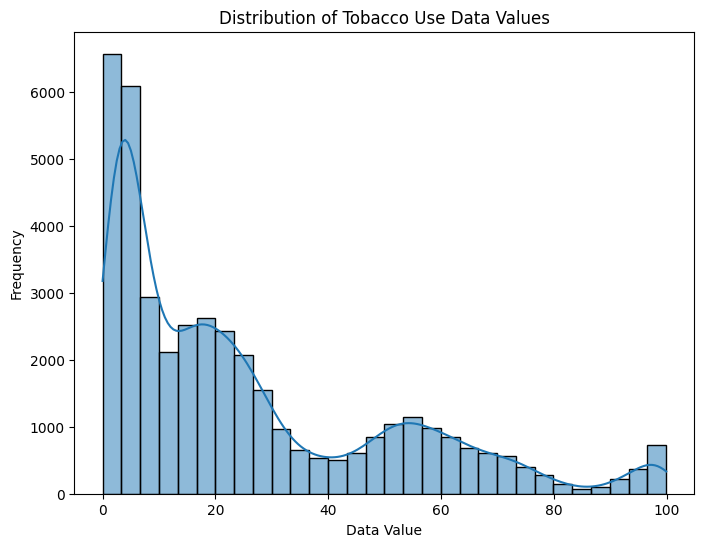

In [37]:
plt.figure(figsize=(8, 6))
sns.histplot(tobacco_use_df['Data_Value'].dropna(), bins=30, kde=True)
plt.title('Distribution of Tobacco Use Data Values')
plt.xlabel('Data Value')
plt.ylabel('Frequency')
plt.show()


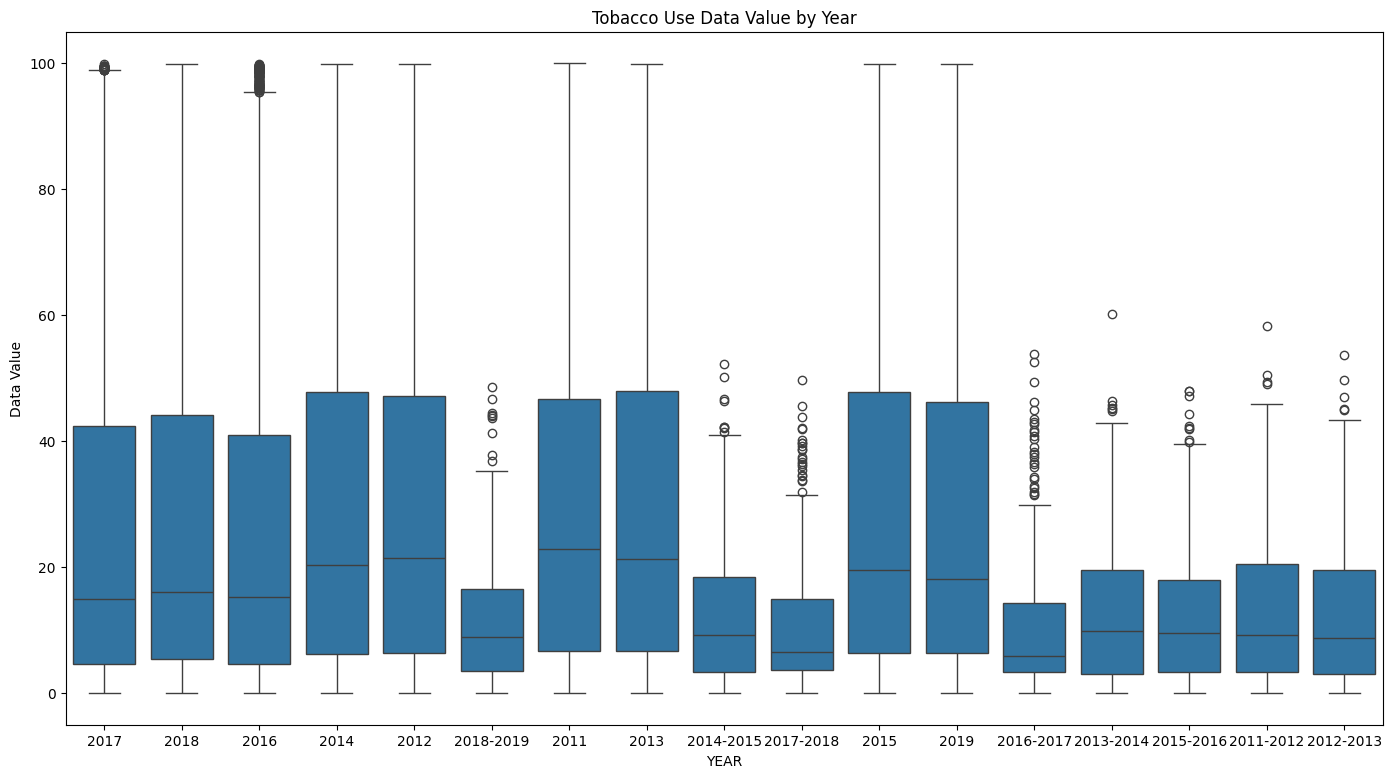

In [38]:
plt.figure(figsize=(17, 9))
sns.boxplot(data=tobacco_use_df, x='YEAR', y='Data_Value')
plt.title('Tobacco Use Data Value by Year')
plt.xlabel('YEAR')
plt.ylabel('Data Value')
plt.show()

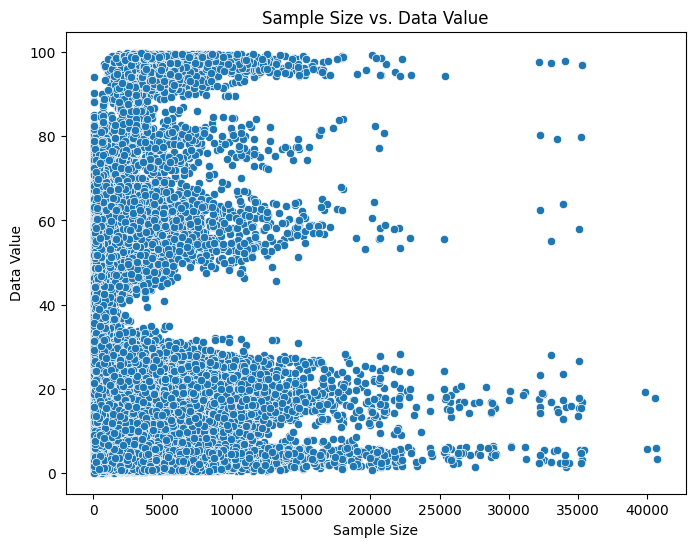

In [39]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=tobacco_use_df, x='Sample_Size', y='Data_Value')
plt.title('Sample Size vs. Data Value')
plt.xlabel('Sample Size')
plt.ylabel('Data Value')
plt.show()


In [40]:

numeric_columns = tobacco_use_df_cleaned.select_dtypes(include=['float64', 'int64'])

# Calculate Q1, Q3, and IQR for numeric columns
Q1 = numeric_columns.quantile(0.25)
Q3 = numeric_columns.quantile(0.75)
IQR = Q3 - Q1

# Identify outliers in numeric columns
outliers = ((numeric_columns < (Q1 - 1.5 * IQR)) | (numeric_columns > (Q3 + 1.5 * IQR)))
print("Numeric Column Outliers:\n", outliers.sum())



Numeric Column Outliers:
 Data_Value               1326
Data_Value_Std_Err       2822
Low_Confidence_Limit     2021
High_Confidence_Limit       0
Sample_Size              2361
DisplayOrder                0
dtype: int64


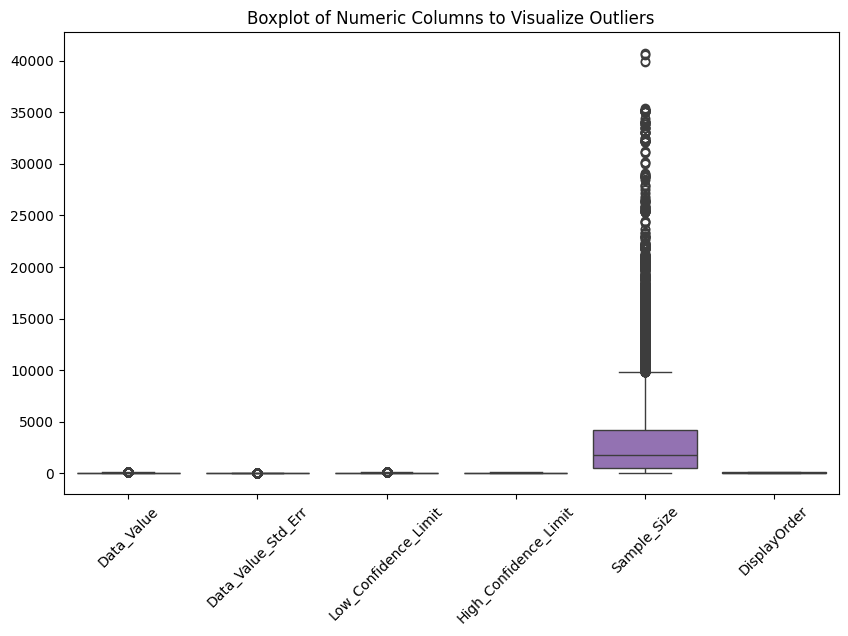

In [41]:
# Select numeric columns
numeric_columns = tobacco_use_df_cleaned.select_dtypes(include=['float64', 'int64'])
# Plot numeric columns
plt.figure(figsize=(10, 6))
sns.boxplot(data=numeric_columns)
plt.title("Boxplot of Numeric Columns to Visualize Outliers")
plt.xticks(rotation=45)
plt.show()

In [42]:
deaths_df = pd.read_csv('/content/Monthly_Provisional_Counts_of_Deaths_2020-2023.csv')
deaths_df

,Data As Of,Start Date,End Date,Jurisdiction of Occurrence,Year,Month,All Cause,Natural Cause,Septicemia,Malignant Neoplasms,...,Intentional Self-Harm (Suicide),Assault (Homicide),Drug Overdose,COVID-19 (Multiple Cause of Death),COVID-19 (Underlying Cause of Death),flag_accid,flag_mva,flag_suic,flag_homic,flag_drugod
0,09/27/2023,01/01/2020,01/31/2020,United States,2020,1,264681,242914,3687,52635,...,4040.0,1708.0,6547.0,6,4,NaN,NaN,NaN,NaN,NaN
1,09/27/2023,02/01/2020,02/29/2020,United States,2020,2,244966,224343,3324,48764,...,3672.0,1471.0,6435.0,25,20,NaN,NaN,NaN,NaN,NaN
2,09/27/2023,03/01/2020,03/31/2020,United States,2020,3,269806,247634,3669,51640,...,3952.0,1693.0,7268.0,7175,6785,NaN,NaN,NaN,NaN,NaN
3,09/27/2023,04/01/2020,04/30/2020,United States,2020,4,322424,300780,3366,48773,...,3480.0,1756.0,7938.0,65553,62014,NaN,NaN,NaN,NaN,NaN
4,09/27/2023,05/01/2020,05/31/2020,United States,2020,5,280564,255489,3085,49012,...,3769.0,2067.0,9466.0,38330,35279,NaN,NaN,NaN,NaN,NaN
5,09/27/2023,06/01/2020,06/30/2020,United States,2020,6,250456,225455,3036,47962,...,3985.0,2261.0,8212.0,18026,15827,NaN,NaN,NaN,NaN,NaN
6,09/27/2023,07/01/2020,07/31/2020,United States,2020,7,279012,252481,3127,50626,...,4184.0,2426.0,8583.0,31135,28279,NaN,NaN,NaN,NaN,NaN
7,09/27/2023,08/01/2020,08/31/2020,United States,2020,8,277282,251071,3268,51209,...,4055.0,2348.0,8351.0,29913,27031,NaN,NaN,NaN,NaN,NaN
8,09/27/2023,09/01/2020,09/30/2020,United States,2020,9,257190,232827,3136,49671,...,3925.0,2191.0,7589.0,19158,16858,NaN,NaN,NaN,NaN,NaN
9,09/27/2023,10/01/2020,10/31/2020,United States,2020,10,273906,249366,3250,51255,...,3804.0,2368.0,7486.0,24930,22083,NaN,NaN,NaN,NaN,NaN


In [43]:
deaths_df.head()


,Data As Of,Start Date,End Date,Jurisdiction of Occurrence,Year,Month,All Cause,Natural Cause,Septicemia,Malignant Neoplasms,...,Intentional Self-Harm (Suicide),Assault (Homicide),Drug Overdose,COVID-19 (Multiple Cause of Death),COVID-19 (Underlying Cause of Death),flag_accid,flag_mva,flag_suic,flag_homic,flag_drugod
0,09/27/2023,01/01/2020,01/31/2020,United States,2020,1,264681,242914,3687,52635,...,4040.0,1708.0,6547.0,6,4,NaN,NaN,NaN,NaN,NaN
1,09/27/2023,02/01/2020,02/29/2020,United States,2020,2,244966,224343,3324,48764,...,3672.0,1471.0,6435.0,25,20,NaN,NaN,NaN,NaN,NaN
2,09/27/2023,03/01/2020,03/31/2020,United States,2020,3,269806,247634,3669,51640,...,3952.0,1693.0,7268.0,7175,6785,NaN,NaN,NaN,NaN,NaN
3,09/27/2023,04/01/2020,04/30/2020,United States,2020,4,322424,300780,3366,48773,...,3480.0,1756.0,7938.0,65553,62014,NaN,NaN,NaN,NaN,NaN
4,09/27/2023,05/01/2020,05/31/2020,United States,2020,5,280564,255489,3085,49012,...,3769.0,2067.0,9466.0,38330,35279,NaN,NaN,NaN,NaN,NaN


In [44]:
deaths_df.columns

Index(['Data As Of', 'Start Date', 'End Date', 'Jurisdiction of Occurrence',
       'Year', 'Month', 'All Cause', 'Natural Cause', 'Septicemia',
       'Malignant Neoplasms', 'Diabetes Mellitus', 'Alzheimer Disease',
       'Influenza and Pneumonia', 'Chronic Lower Respiratory Diseases',
       'Other Diseases of Respiratory System',
       'Nephritis, Nephrotic Syndrome and Nephrosis',
       'Symptoms, Signs and Abnormal Clinical and Laboratory Findings, Not Elsewhere Classified',
       'Diseases of Heart', 'Cerebrovascular Diseases',
       'Accidents (Unintentional Injuries)', 'Motor Vehicle Accidents',
       'Intentional Self-Harm (Suicide)', 'Assault (Homicide)',
       'Drug Overdose', 'COVID-19 (Multiple Cause of Death)',
       'COVID-19 (Underlying Cause of Death)', 'flag_accid', 'flag_mva',
       'flag_suic', 'flag_homic', 'flag_drugod'],
      dtype='object')

In [45]:
deaths_df.shape

(45, 31)

In [46]:
deaths_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 31 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   Data As Of                                                                               45 non-null     object 
 1   Start Date                                                                               45 non-null     object 
 2   End Date                                                                                 45 non-null     object 
 3   Jurisdiction of Occurrence                                                               45 non-null     object 
 4   Year                                                                                     45 non-null     int64  
 5   Month                                                             

In [47]:
missing_values = deaths_df.isnull().sum()
missing_values

,0
Data As Of,0
Start Date,0
End Date,0
Jurisdiction of Occurrence,0
Year,0
Month,0
All Cause,0
Natural Cause,0
Septicemia,0
Malignant Neoplasms,0


In [48]:
columns_to_drop = ['flag_accid', 'flag_mva', 'flag_suic', 'flag_homic', 'flag_drugod']
deaths_df_cleaned = deaths_df.drop(columns=columns_to_drop, errors='ignore')
deaths_df_cleaned


,Data As Of,Start Date,End Date,Jurisdiction of Occurrence,Year,Month,All Cause,Natural Cause,Septicemia,Malignant Neoplasms,...,"Symptoms, Signs and Abnormal Clinical and Laboratory Findings, Not Elsewhere Classified",Diseases of Heart,Cerebrovascular Diseases,Accidents (Unintentional Injuries),Motor Vehicle Accidents,Intentional Self-Harm (Suicide),Assault (Homicide),Drug Overdose,COVID-19 (Multiple Cause of Death),COVID-19 (Underlying Cause of Death)
0,09/27/2023,01/01/2020,01/31/2020,United States,2020,1,264681,242914,3687,52635,...,2755,60896,14113,15012.0,2914.0,4040.0,1708.0,6547.0,6,4
1,09/27/2023,02/01/2020,02/29/2020,United States,2020,2,244966,224343,3324,48764,...,2599,56851,12818,14497.0,2910.0,3672.0,1471.0,6435.0,25,20
2,09/27/2023,03/01/2020,03/31/2020,United States,2020,3,269806,247634,3669,51640,...,2808,60229,13742,15444.0,2874.0,3952.0,1693.0,7268.0,7175,6785
3,09/27/2023,04/01/2020,04/30/2020,United States,2020,4,322424,300780,3366,48773,...,2826,62285,13420,15493.0,2569.0,3480.0,1756.0,7938.0,65553,62014
4,09/27/2023,05/01/2020,05/31/2020,United States,2020,5,280564,255489,3085,49012,...,2524,56561,12776,18205.0,3365.0,3769.0,2067.0,9466.0,38330,35279
5,09/27/2023,06/01/2020,06/30/2020,United States,2020,6,250456,225455,3036,47962,...,2496,53590,12315,17784.0,4026.0,3985.0,2261.0,8212.0,18026,15827
6,09/27/2023,07/01/2020,07/31/2020,United States,2020,7,279012,252481,3127,50626,...,2887,57193,13024,18823.0,4107.0,4184.0,2426.0,8583.0,31135,28279
7,09/27/2023,08/01/2020,08/31/2020,United States,2020,8,277282,251071,3268,51209,...,2793,56245,13094,18762.0,4226.0,4055.0,2348.0,8351.0,29913,27031
8,09/27/2023,09/01/2020,09/30/2020,United States,2020,9,257190,232827,3136,49671,...,2583,53889,12771,17234.0,4083.0,3925.0,2191.0,7589.0,19158,16858
9,09/27/2023,10/01/2020,10/31/2020,United States,2020,10,273906,249366,3250,51255,...,2687,56898,13615,17262.0,4192.0,3804.0,2368.0,7486.0,24930,22083


In [49]:
deaths_df_cleaned.shape

(45, 26)

In [50]:
# Count the number of duplicate rows
num_duplicates = deaths_df.duplicated().sum()

print("Number of duplicate rows:", num_duplicates)


Number of duplicate rows: 0


In [51]:
deaths_df.describe()


,Year,Month,All Cause,Natural Cause,Septicemia,Malignant Neoplasms,Diabetes Mellitus,Alzheimer Disease,Influenza and Pneumonia,Chronic Lower Respiratory Diseases,...,"Symptoms, Signs and Abnormal Clinical and Laboratory Findings, Not Elsewhere Classified",Diseases of Heart,Cerebrovascular Diseases,Accidents (Unintentional Injuries),Motor Vehicle Accidents,Intentional Self-Harm (Suicide),Assault (Homicide),Drug Overdose,COVID-19 (Multiple Cause of Death),COVID-19 (Underlying Cause of Death)
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,...,45.000000,45.000000,45.000000,38.000000,38.000000,38.000000,38.000000,38.000000,45.000000,45.000000
mean,2021.400000,6.200000,273418.688889,249081.488889,3398.177778,49997.444444,8281.688889,10067.200000,3855.822222,12108.444444,...,3690.755556,57090.688889,13385.466667,18299.289474,3766.763158,3998.868421,2094.131579,8599.578947,25484.288889,22004.666667
std,1.095445,3.388483,40785.099610,38437.862715,386.139299,3896.432223,1114.210255,1396.990249,1295.509680,1604.617153,...,2399.768314,6433.987975,1342.994815,1479.226111,503.483940,238.028067,238.285562,835.895624,26010.271383,24162.055113
min,2020.000000,1.000000,118127.000000,116426.000000,1605.000000,26780.000000,3332.000000,4993.000000,1488.000000,5657.000000,...,2478.000000,25048.000000,6505.000000,14497.000000,2569.000000,3480.000000,1471.000000,6435.000000,6.000000,4.000000
25%,2020.000000,3.000000,251959.000000,227960.000000,3253.000000,49280.000000,7766.000000,9139.000000,3121.000000,11258.000000,...,2636.000000,55351.000000,12964.000000,17653.250000,3459.000000,3842.000000,1943.250000,8019.250000,7633.000000,5799.000000
50%,2021.000000,6.000000,268815.000000,242914.000000,3366.000000,50661.000000,8316.000000,9968.000000,3412.000000,11864.000000,...,2886.000000,56766.000000,13297.000000,18755.000000,3929.500000,4015.500000,2121.000000,8902.500000,14877.000000,10018.000000
75%,2022.000000,9.000000,289362.000000,263621.000000,3615.000000,51604.000000,8641.000000,10923.000000,3838.000000,12792.000000,...,3241.000000,59240.000000,13908.000000,19244.750000,4180.750000,4148.250000,2269.250000,9285.750000,38330.000000,35279.000000
max,2023.000000,12.000000,373642.000000,348017.000000,4173.000000,53402.000000,11057.000000,13195.000000,7990.000000,15533.000000,...,15189.000000,71528.000000,16375.000000,20434.000000,4513.000000,4407.000000,2426.000000,9665.000000,105566.000000,96438.000000


In [52]:
deaths_df.shape

(45, 31)

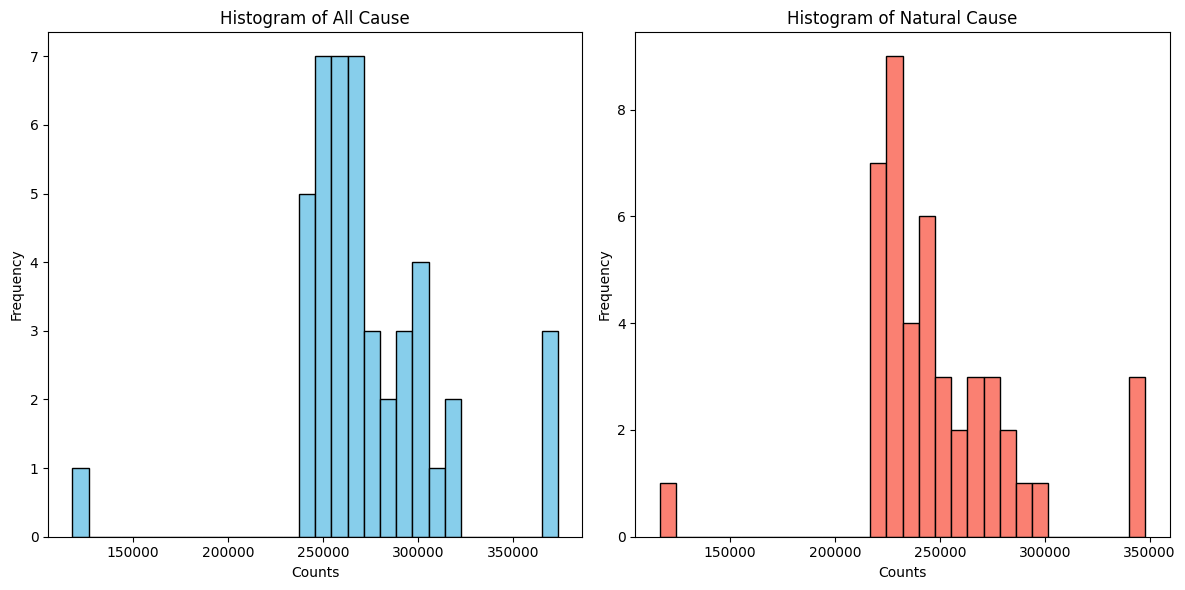

In [53]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(deaths_df['All Cause'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of All Cause')
plt.xlabel('Counts')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(deaths_df['Natural Cause'], bins=30, color='salmon', edgecolor='black')
plt.title('Histogram of Natural Cause')
plt.xlabel('Counts')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


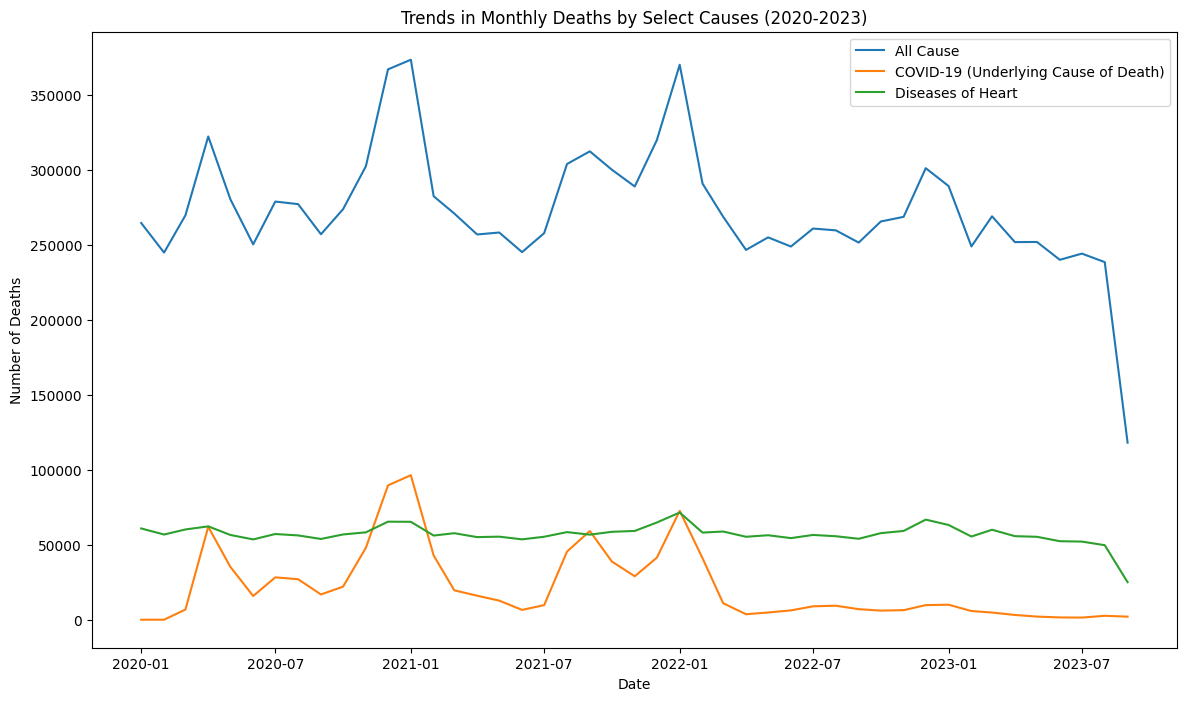

In [54]:
# Convert 'Year' and 'Month' to datetime
deaths_df['Date'] = pd.to_datetime(deaths_df[['Year', 'Month']].assign(Day=1))

plt.figure(figsize=(14, 8))
causes = ['All Cause', 'COVID-19 (Underlying Cause of Death)', 'Diseases of Heart']
for cause in causes:
    sns.lineplot(data=deaths_df, x='Date', y=cause, label=cause)

plt.title('Trends in Monthly Deaths by Select Causes (2020-2023)')
plt.xlabel('Date')
plt.ylabel('Number of Deaths')
plt.legend()
plt.show()


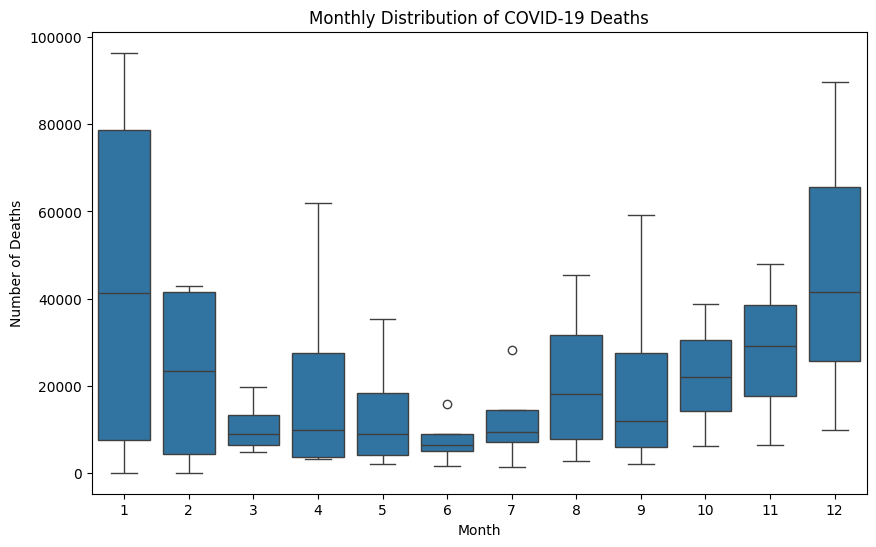

In [55]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=deaths_df, x='Month', y='COVID-19 (Underlying Cause of Death)')
plt.title('Monthly Distribution of COVID-19 Deaths')
plt.xlabel('Month')
plt.ylabel('Number of Deaths')
plt.show()


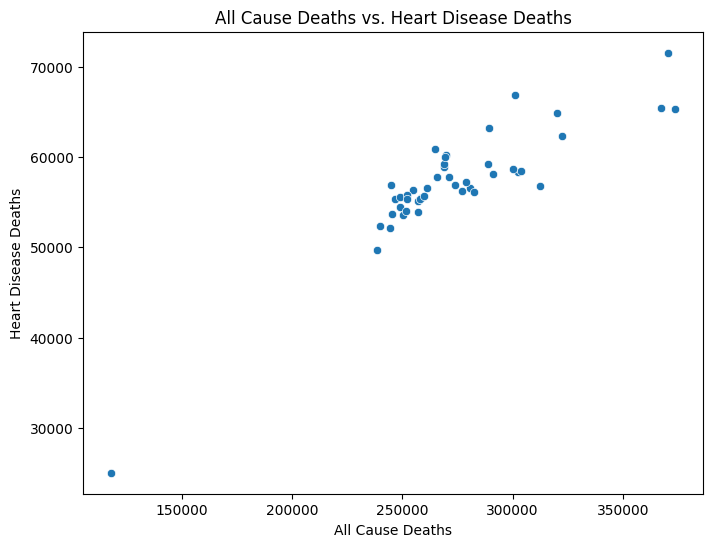

In [56]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=deaths_df, x='All Cause', y='Diseases of Heart')
plt.title('All Cause Deaths vs. Heart Disease Deaths')
plt.xlabel('All Cause Deaths')
plt.ylabel('Heart Disease Deaths')
plt.show()

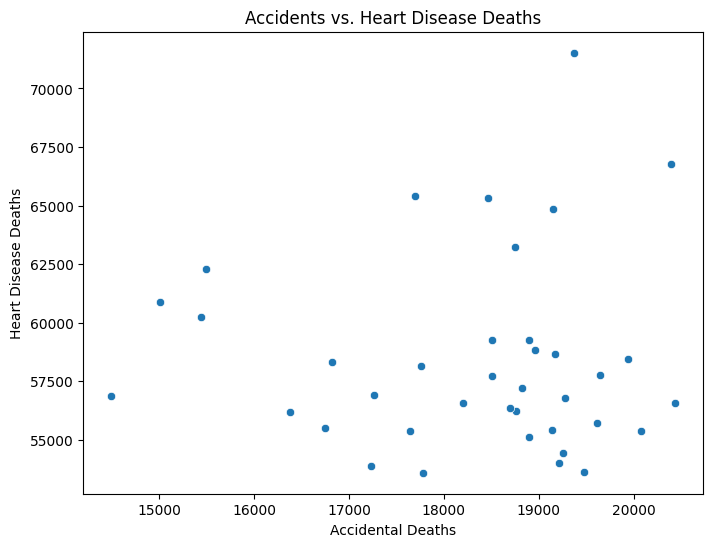

In [57]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=deaths_df, x='Accidents (Unintentional Injuries)', y='Diseases of Heart')
plt.title('Accidents vs. Heart Disease Deaths')
plt.xlabel('Accidental Deaths')
plt.ylabel('Heart Disease Deaths')
plt.show()


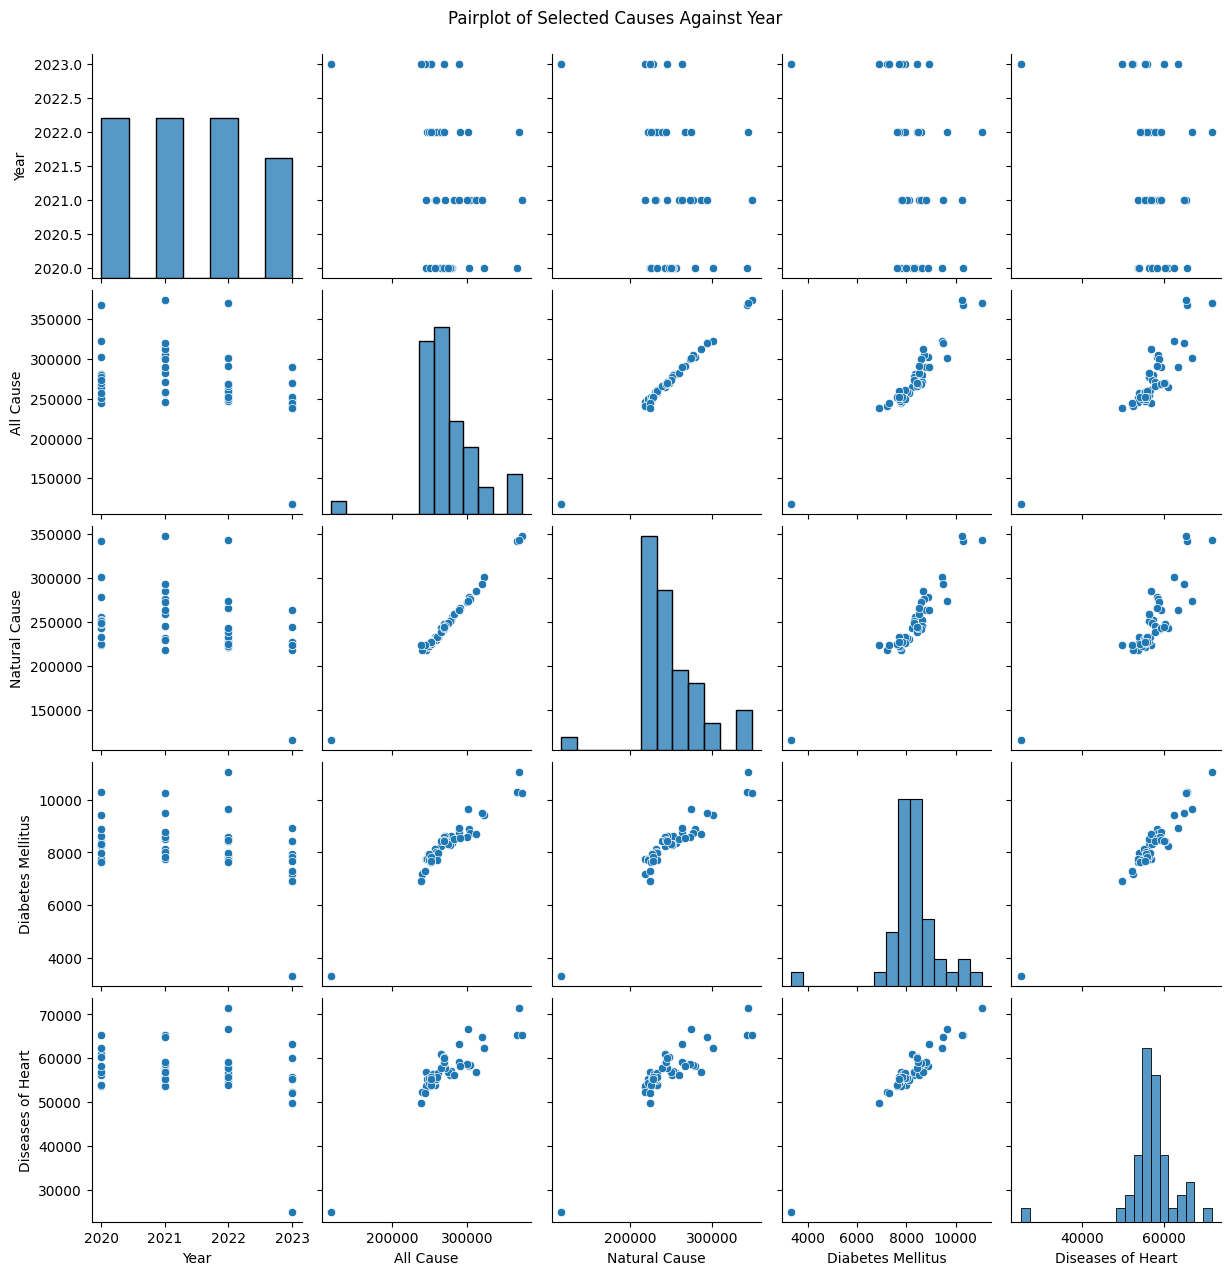

In [58]:
# Define the columns to include in the pairplot (only 5 columns)
columns_to_include = ['Year', 'All Cause', 'Natural Cause',
                      'Diabetes Mellitus', 'Diseases of Heart']
# Select the relevant columns from the DataFrame
selected_deaths_df = deaths_df[columns_to_include]
# Create a pairplot
sns.pairplot(selected_deaths_df)
plt.suptitle('Pairplot of Selected Causes Against Year', y=1.02)
plt.show()

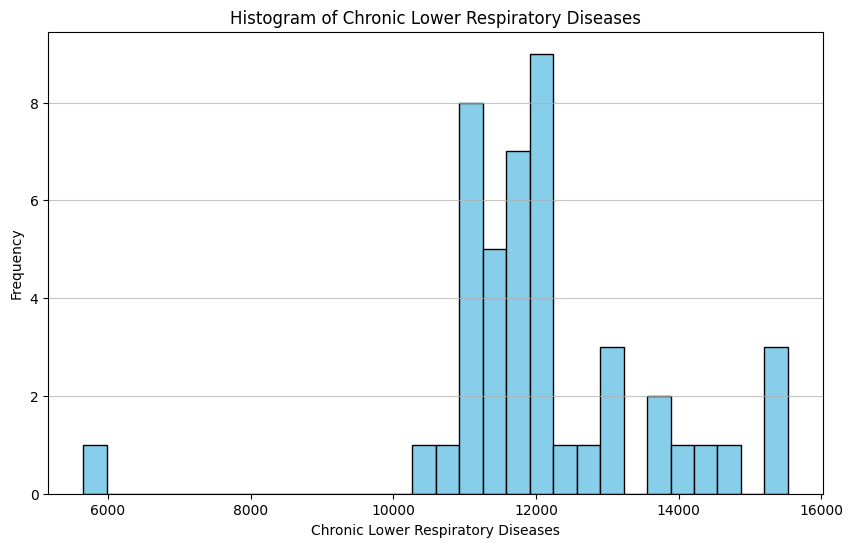

In [59]:
# Create a histogram for 'Chronic Lower Respiratory Diseases'
plt.figure(figsize=(10, 6))
plt.hist(deaths_df['Chronic Lower Respiratory Diseases'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Chronic Lower Respiratory Diseases')
plt.xlabel('Chronic Lower Respiratory Diseases')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


In [60]:
# Select numeric columns
numeric_columns = deaths_df.select_dtypes(include=['float64', 'int64'])

# Calculate Q1, Q3, and IQR
Q1 = numeric_columns.quantile(0.25)
Q3 = numeric_columns.quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = ((numeric_columns < (Q1 - 1.5 * IQR)) | (numeric_columns > (Q3 + 1.5 * IQR)))
print("Outliers:\n", outliers.sum())


Outliers:
 Year                                                                                       0
Month                                                                                      0
All Cause                                                                                  4
Natural Cause                                                                              4
Septicemia                                                                                 2
Malignant Neoplasms                                                                        1
Diabetes Mellitus                                                                          4
Alzheimer Disease                                                                          1
Influenza and Pneumonia                                                                    8
Chronic Lower Respiratory Diseases                                                         4
Other Diseases of Respiratory System                       

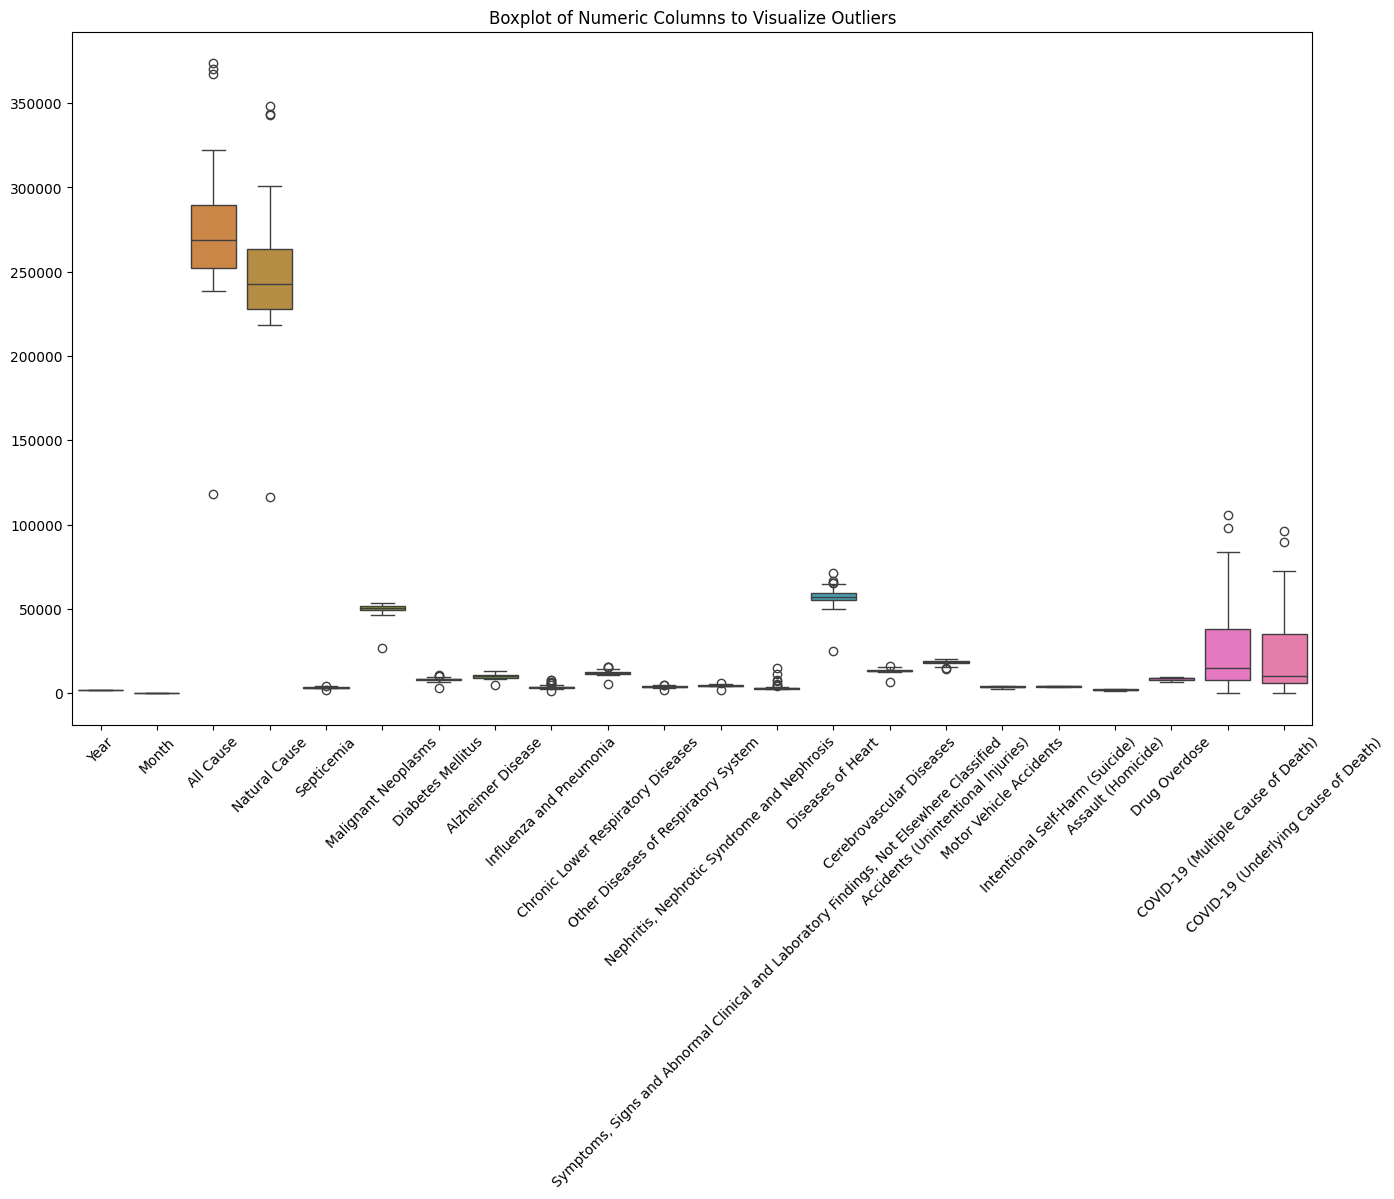

In [61]:
# Select numeric columns
numeric_columns = deaths_df.select_dtypes(include=['float64', 'int64'])


# Create boxplots for all numeric columns
plt.figure(figsize=(16, 9))
sns.boxplot(data=numeric_columns)
plt.title("Boxplot of Numeric Columns to Visualize Outliers")
plt.xticks(rotation=45)
plt.show()